- The data is collected through a questionnaire administered to students in US schools. Each column corresponds to a question response. [Link to Questionnaire](https://ww2.amstat.org/censusatschool/pdfs/C@SQuestionnaire.pdf). There are 40 questions overall. Some questions ask for multiple responses: 13 (6), 33 (12) so the total columns in the data should be: 40+5+11=56.


- The first 13 questions are the original international questions common to the countries participating in the Census at School program

- Questions that are numerical: 2, 4, 5, 6, 7, 9, 10, 11, 13, 14, 16, 17, 26, 27, 28, 31, 32, 33

- The remaining questions are nominal (34 is ordinal)

In [13]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import re

In [14]:
# Load the dataset into a dataframe

df = pd.read_csv('census.csv')

# df containing responses from questionnaire
df_q = df.iloc[:, 4:]

# the other 4 columns aside from questionnaire responses are Country, 
# Region, DataYear (collection year) and ClassGrade
# df containing information gained from outside the survey
# We know that the Country is always USA so drop that column
df_meta = df.iloc[:, :4].drop(columns='Country')

print(df_q.head())
print(df_meta.head())

   Gender  Ageyears        Handed Height_cm Footlength_cm Armspan_cm  \
0    Male      17.0  Right-Handed       182            33        193   
1    Male      16.0  Right-Handed        70            32        170   
2  Female      18.0  Right-Handed       5'3           NaN        NaN   
3  Female      17.0  Right-Handed       172            26        177   
4  Female      17.0  Right-Handed       165            25        168   

   Languages_spoken Travel_to_School Travel_time_to_School  Reaction_time  \
0               1.0              Car                    10          0.324   
1               2.0              Car                    30          0.340   
2               1.0              Car                   NaN          3.061   
3               1.0              Car                     7          0.328   
4               1.0              Car                    10          0.501   

   ... Watching_TV_Hours Paid_Work_Hours  Work_At_Home_Hours  \
0  ...                 4              15

In [28]:
display(df_meta['DataYear'].describe())

count     452.000000
mean     2018.250000
std         3.798923
min      2010.000000
25%      2016.000000
50%      2018.000000
75%      2021.250000
max      2024.000000
Name: DataYear, dtype: float64

In [15]:

print(f"Samples: {df_q.shape[0]}, Questions: {df_q.shape[1]}")
print(f"Samples: {df_meta.shape[0]}, Questions: {df_meta.shape[1]}")


# create a question index mapping questionnaire qs to columns
lengths = np.ones(40, dtype=int)
lengths[12] = 6
lengths[32] = 12
assert np.sum(lengths) == 56

cuts = np.cumsum(lengths)[:-1]
q_idx = dict(enumerate(np.split(df_q.columns.to_numpy(), cuts), 1))

# the numeric questions
numeric_qs = np.array([2, 4, 5, 6, 7, 9, 10, 11, 13, 
              14, 16, 17, 26, 27, 28, 31, 32, 33])

cat_qs = np.arange(1, 41)[~np.isin(range(1, 41), numeric_qs)]

numeric_cols = np.concat([q_idx[i] for i in numeric_qs])

cat_cols = np.concat([q_idx[i] for i in cat_qs])


print("numeric columns:", numeric_cols, sep='\n')

print("categorical columns:", cat_cols, sep='\n')


Samples: 452, Questions: 56
Samples: 452, Questions: 3
numeric columns:
['Ageyears' 'Height_cm' 'Footlength_cm' 'Armspan_cm' 'Languages_spoken'
 'Travel_time_to_School' 'Reaction_time' 'Score_in_memory_game'
 'Importance_reducing_pollution' 'Importance_recycling_rubbish'
 'Importance_conserving_water' 'Importance_saving_energy'
 'Importance_owning_computer' 'Importance_Internet_access'
 'Left_Footlength_cm' 'Index_Fingerlength_mm' 'Ring_Fingerlength_mm'
 'Sleep_Hours_Schoolnight' 'Sleep_Hours_Non_Schoolnight' 'Home_Occupants'
 'Text_Messages_Sent_Yesterday' 'Text_Messages_Received_Yesterday'
 'Hanging_Out_With_Friends_Hours' 'Talking_On_Phone_Hours'
 'Doing_Homework_Hours' 'Doing_Things_With_Family_Hours'
 'Outdoor_Activities_Hours' 'Video_Games_Hours' 'Social_Websites_Hours'
 'Texting_Messaging_Hours' 'Computer_Use_Hours' 'Watching_TV_Hours'
 'Paid_Work_Hours' 'Work_At_Home_Hours']
categorical columns:
['Gender' 'Handed' 'Travel_to_School' 'Favourite_physical_activity'
 'Longer_foot' 

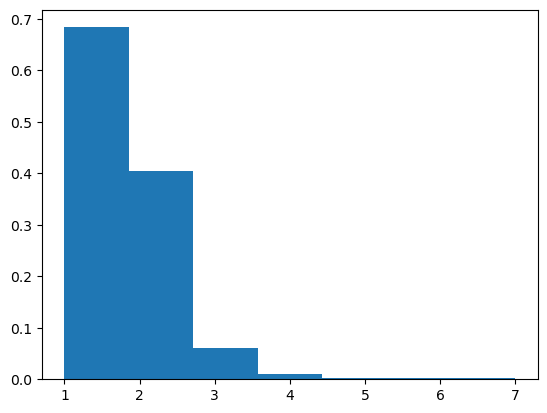

0.41150442477876104


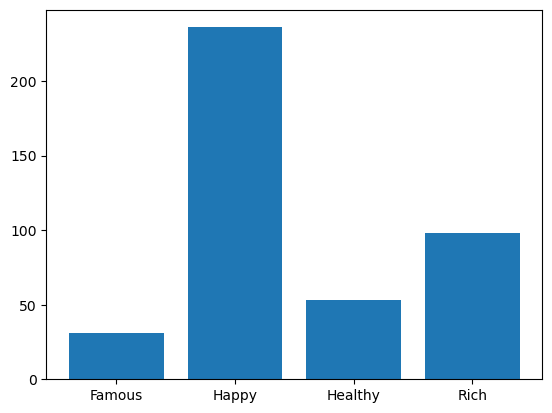

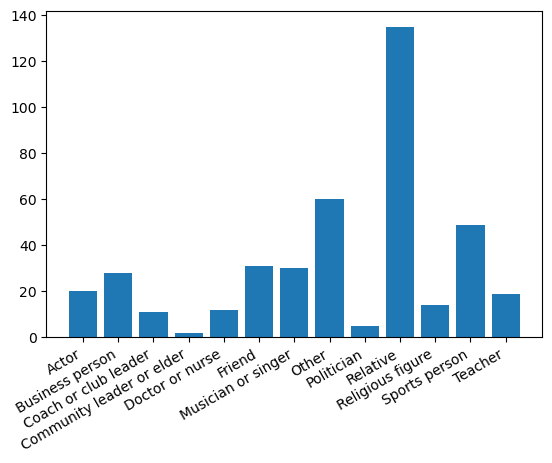

In [16]:
num_lang = df_q['Languages_spoken'].to_numpy(dtype=float)
age = df_q['Ageyears']
plt.hist(num_lang, bins=7, density='True')
plt.show()

print(np.mean(num_lang > 1))

plt.bar(*np.unique_counts(df_q['Preferred_Status'].dropna()))
plt.show()

fig, ax = plt.subplots()
ax.bar(*np.unique_counts(df_q['Role_Model_Type'].dropna()))
fig.autofmt_xdate()
plt.show()


In [17]:
def is_float_like(x):
    if pd.isna(x):
        return True
    try:
        float(x)
        return True
    except (TypeError, ValueError):
        return False
    
def find_non_numeric(arr):  
    is_float = np.vectorize(is_float_like)
    cols = []
    for i in range(arr.shape[1]):
        col = arr[:, i]
        mask = is_float(col)
        cols.append(col[~mask].tolist())

    return cols
    
arr = np.array([['3.1', 'NaN', "abc"], ['2', 'nan', "abc"]])
    
find_non_numeric(arr)


[[], [], ['abc', 'abc']]

In [18]:
numeric = df_q[numeric_cols].to_numpy()

print(*zip(numeric_cols, find_non_numeric(numeric)), sep='\n')

('Ageyears', [])
('Height_cm', ["5'3", "5'11", '4”10', "5'2", "4'9", "5'4", '5,8', "4'10", '5’2”', "5'11", "5'6", '177cm', '5 11', "5'5", '5´3', '5\'3"', '5\' 3"', '158cm', '157cm', "5'4", '172cm', "5' 11"])
('Footlength_cm', ['29cm', '29cm', '24cm', '20cm', '31cm', '12cm'])
('Armspan_cm', ['56cm', '189cm', '160cm', '165cm', '71cm'])
('Languages_spoken', [])
('Travel_time_to_School', ['5-10', '3 min', '7 ish', '21 m', '5-7', '1hr', '5 min', '12min', 'Oof', '14min', '20-25', '1hour'])
('Reaction_time', [])
('Score_in_memory_game', ['52 s'])
('Importance_reducing_pollution', [])
('Importance_recycling_rubbish', [])
('Importance_conserving_water', ['?'])
('Importance_saving_energy', [])
('Importance_owning_computer', [])
('Importance_Internet_access', [])
('Left_Footlength_cm', ['8cm', '12cm'])
('Index_Fingerlength_mm', ['30mm', 'idk', '8cm', '80mm', '70mm', "3'4"])
('Ring_Fingerlength_mm', ['25mm', 'idk', '7cm', '60 mm', "3'2"])
('Sleep_Hours_Schoolnight', ['7-9', '7-8', '6hr', '6-8', '5

In [19]:
def to_float(x):

    if pd.isna(x):
        return np.nan
    
    if isinstance(x, float):
        return x
    
    x = x.strip().lower()

    # remove spaces
    x = x.replace(" ", "")

    # minutes → hours
    m = re.match(r'(\d+(?:\.\d+)?)min', x)
    if m:
        return float(m.group(1)) / 60

    # hours
    m = re.match(r'(\d+(?:\.\d+)?)(hr|hrs|hour|hours)', x)
    if m:
        return float(m.group(1))

    # ranges → minimum
    m = re.match(r'(\d+)(-|~)(\d+)', x)
    if m:
        return to_float(m.group(1))

    # fraction
    m = re.match(r'(\d+)/(\d+)', x)
    if m:
        val = float(m.group(1)) / float(m.group(2))
        if val < 1:
            return val
        else:
            return np.nan

    # plain number
    if re.match(r'^\d+(\.\d+)?$', x):
        return float(x)

    return np.nan

Q33: ['Hanging_Out_With_Friends_Hours' 'Talking_On_Phone_Hours'
 'Doing_Homework_Hours' 'Doing_Things_With_Family_Hours'
 'Outdoor_Activities_Hours' 'Video_Games_Hours' 'Social_Websites_Hours'
 'Texting_Messaging_Hours' 'Computer_Use_Hours' 'Watching_TV_Hours'
 'Paid_Work_Hours' 'Work_At_Home_Hours']


,Social_Websites_Hours,Computer_Use_Hours,Watching_TV_Hours
count,407.000000,384.000000,407.000000
mean,9.514128,15.563802,6.757985
std,12.343701,16.392198,9.431685
min,0.000000,0.000000,0.000000
25%,2.000000,4.000000,1.000000
50%,5.000000,10.000000,4.000000
75%,12.000000,20.000000,9.000000
max,70.000000,72.000000,70.000000


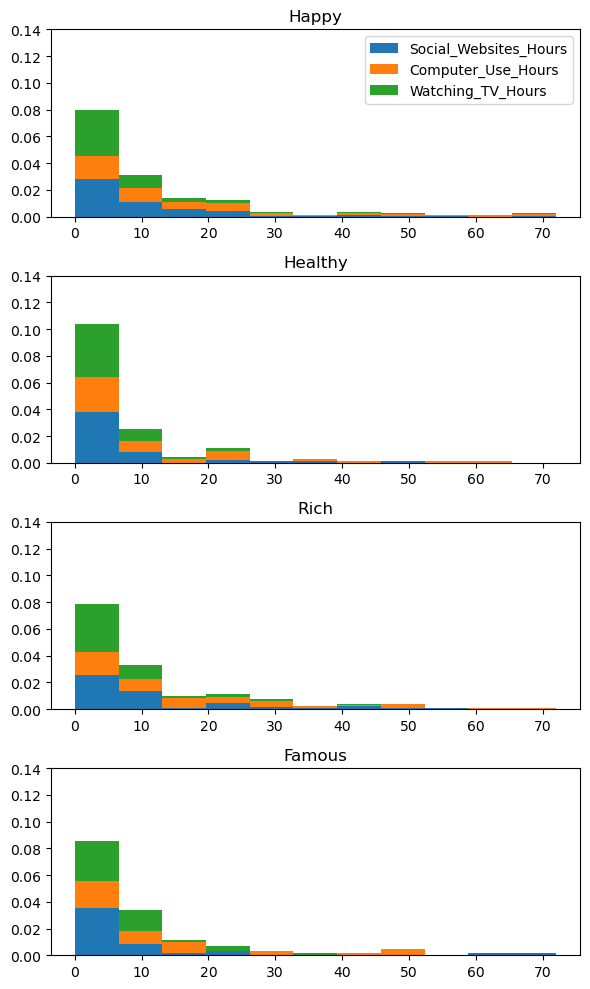

In [50]:
# 16.3.2025 EX1

print('Q33:', q_idx[33])

tech_cols = [
    'Social_Websites_Hours',
    'Computer_Use_Hours',
    'Watching_TV_Hours',
]

tech_hrs = df_q[tech_cols].map(to_float)
status = df_q['Preferred_Status']

# Assume we have 8 * 5 + 32 hours of free time per day
mask = tech_hrs <= 72
tech_hrs = tech_hrs[mask]

# make the choice to replace missing values with 0s 
# tech_hrs.fillna(0, inplace=True)

display(tech_hrs.describe())

find_non_numeric(tech_hrs.to_numpy())

status_labels = ['Happy', 'Healthy', 'Rich', 'Famous']


fig, axes = plt.subplots(4,1)

y_ticks = np.arange(0, 0.14, 0.02)
bins = np.linspace(0, 72, 12)

fig.set_size_inches(6, 10)
for ax, s in zip(axes, status_labels):
    hr = tech_hrs.loc[status == s, :]
    ax.hist(hr.to_numpy(), bins=bins, label=tech_cols,
        density=True, histtype='bar', stacked=True)
    ax.set_title(s)
    ax.set_yticks(y_ticks)
axes[0].legend()
    
plt.tight_layout()


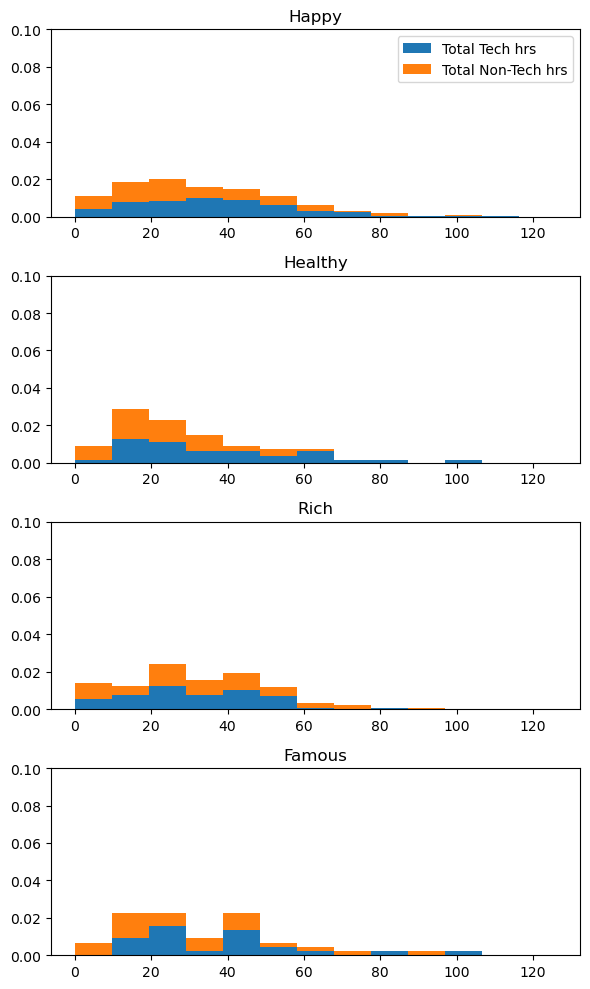

In [ ]:
# EX2
tech_cols = [
    'Social_Websites_Hours',
    'Computer_Use_Hours',
    'Watching_TV_Hours',
    'Video_Games_Hours',
    'Talking_On_Phone_Hours',
    'Texting_Messaging_Hours'
]

nontech_cols = [it for it in q_idx[33] if it not in tech_cols]

hrs = df_q[q_idx[33]].map(to_float)

total_tech_hrs = hrs[tech_cols].sum(axis=1)
total_nontech_hrs = hrs[nontech_cols].sum(axis=1)


# Do not consider entries where the total number of hours is longer
# than typical waking hours.
max_time = 18 * 7
mask = (total_nontech_hrs + total_tech_hrs) < max_time

total_nontech_hrs = total_nontech_hrs[mask]
total_tech_hrs = total_tech_hrs[mask]

total_hrs = pd.concat([total_nontech_hrs, total_tech_hrs],
                      axis=1)

fig, axes = plt.subplots(4,1)

y_ticks = np.arange(0, 0.12, 0.02)
bins = np.linspace(0, max_time, 14)

fig.set_size_inches(6, 10)
for ax, s in zip(axes, status_labels):
    hr = total_hrs[status[mask] == s]
    ax.hist(hr.to_numpy(), bins=bins,
            label=['Total Tech hrs', 'Total Non-Tech hrs'],
        density=True, histtype='barstacked')
    ax.set_title(s)
    ax.set_yticks(y_ticks)

axes[0].legend()
    
plt.tight_layout()



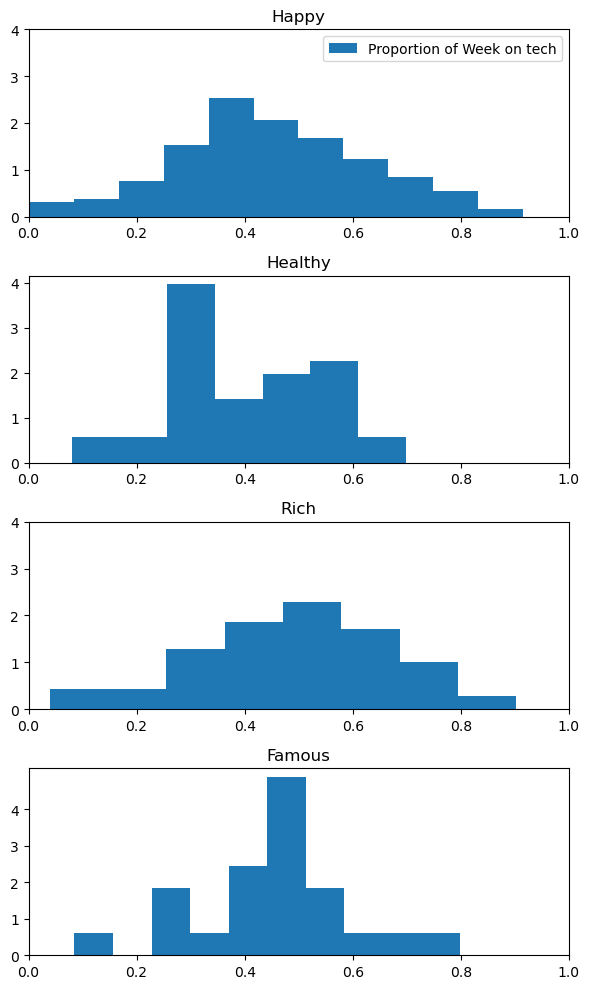

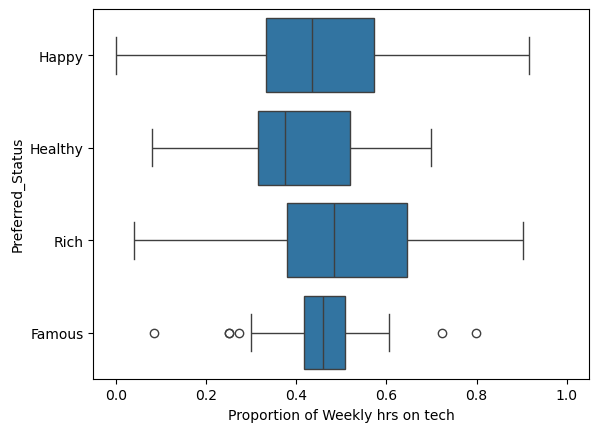

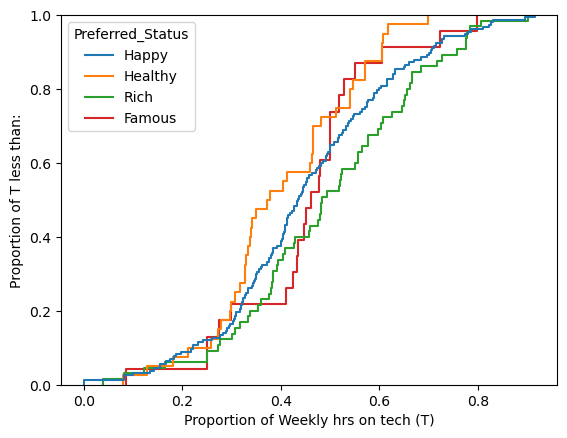

In [ ]:
# EX3
tech_prop = total_tech_hrs / (total_tech_hrs+total_nontech_hrs)

fig, axes = plt.subplots(4,1)

y_ticks = np.arange(0, 5, 1)
bins = np.linspace(0, 1, 15)

fig.set_size_inches(6, 10)
for ax, s in zip(axes, status_labels):
    hr = tech_prop[status[mask] == s]
    ax.hist(hr.to_numpy(), bins='auto',
            label='Proportion of Week on tech', density=True)
    ax.set_title(s)
    ax.set_xlim(0, 1)
    ax.set_yticks(y_ticks)

axes[0].legend()
    
plt.tight_layout()
plt.show()

import seaborn as sns

_, ax = plt.subplots()
sns.boxplot(x=tech_prop, y=status[mask], ax=ax)
ax.set_xlabel('Proportion of Weekly hrs on tech')
ax.set_xlim(-0.05, 1.05)
plt.show()

_, ax = plt.subplots()
sns.ecdfplot(x=tech_prop, hue=status[mask], ax=ax)
ax.set_xlabel('Proportion of Weekly hrs on tech (T)')
ax.set_ylabel('Proportion of T less than:')
plt.show()


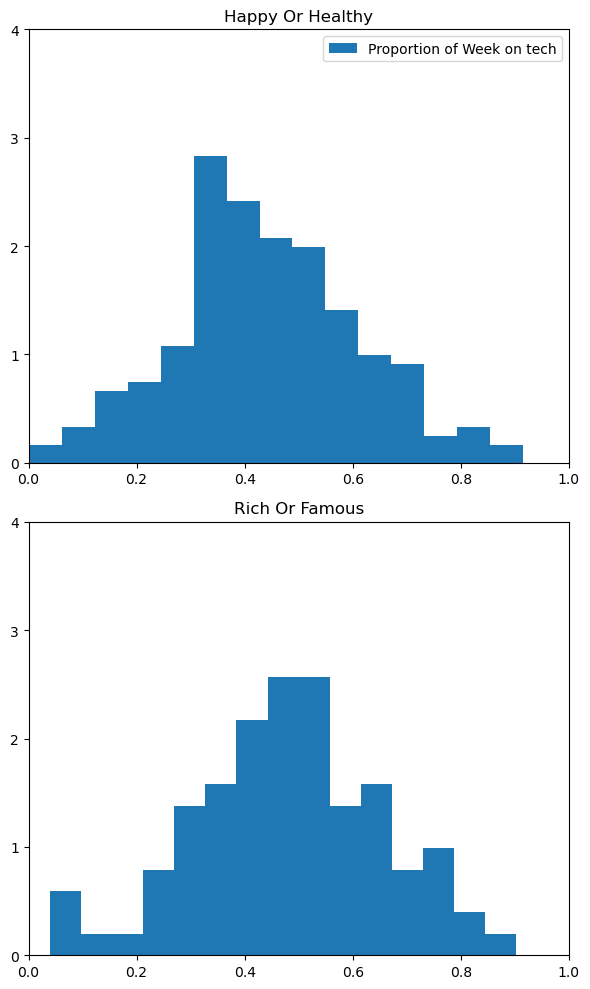

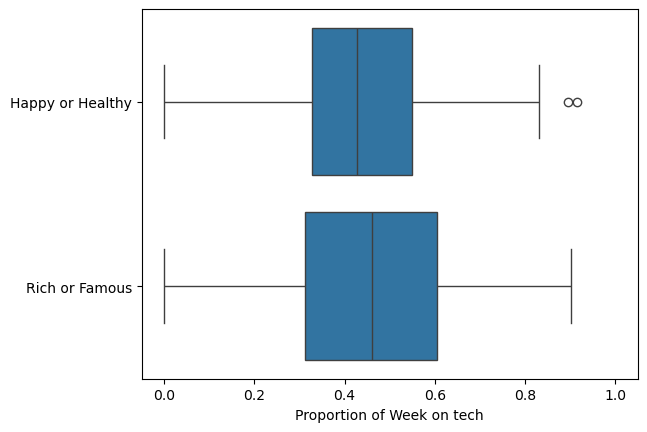

In [ ]:
# EX4
status_groups = [('Happy', 'Healthy'), ('Rich', 'Famous')]

fig, axes = plt.subplots(2,1)

y_ticks = np.arange(0, 5, 1)
bins = np.linspace(0, 1, 15)

fig.set_size_inches(6, 10)
for ax, s in zip(axes, status_groups):
    hr = tech_prop[status[mask].isin(s)]
    ax.hist(hr.to_numpy(), bins=15,
            label='Proportion of Week on tech', density=True)
    ax.set_title("{0} Or {1}".format(*s))
    ax.set_xlim(0, 1)
    ax.set_yticks(y_ticks)

axes[0].legend()
    
plt.tight_layout()
plt.show()

import seaborn as sns

_, ax = plt.subplots()

label = np.where(status[mask].isin(status_groups[0]), 
                 'Happy or Healthy', 'Rich or Famous')

sns.boxplot(x=tech_prop, y=label, ax=ax)
ax.set_xlabel('Proportion of Week on tech')
ax.set_xlim(-0.05, 1.05)
plt.show()


Pressure from schoolwork,Very little,Some,A lot
Highest planned level of education,,,
Graduate degree,40,118,103
Undergraduate degree,8,33,15
Some college,9,22,15
High school,4,5,9
Less than high school,0,2,1
Other,2,12,8


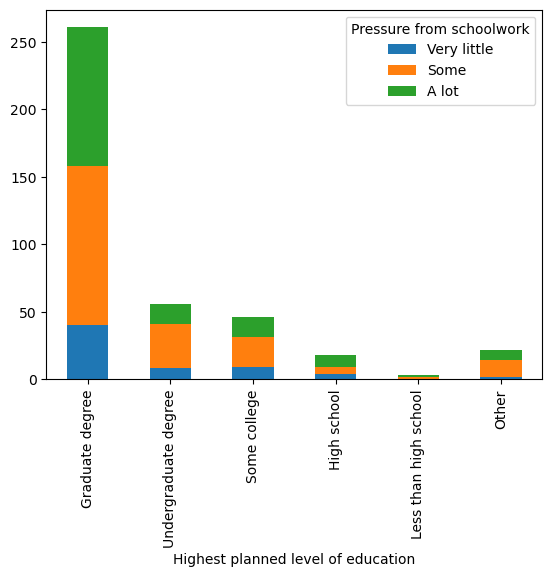

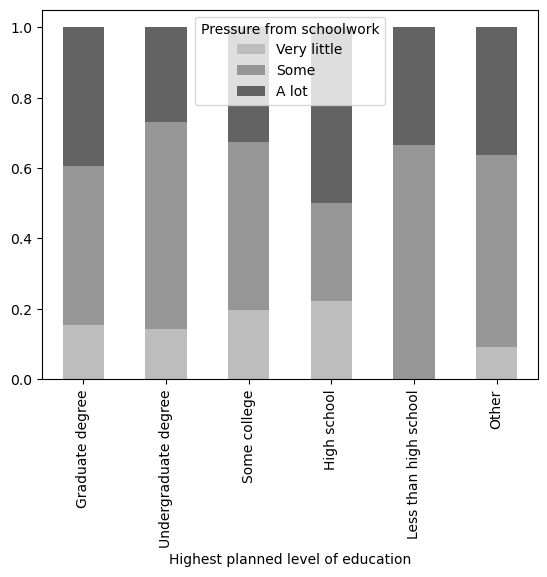

Highest planned level of education,Graduate degree,Undergraduate degree,Some college,High school,Less than high school,Other
Hours on Homework Quartile,,,,,,
1,66,11,16,10,0,8
2,61,21,16,5,2,2
3,64,16,13,3,0,4
4,69,8,2,1,1,7


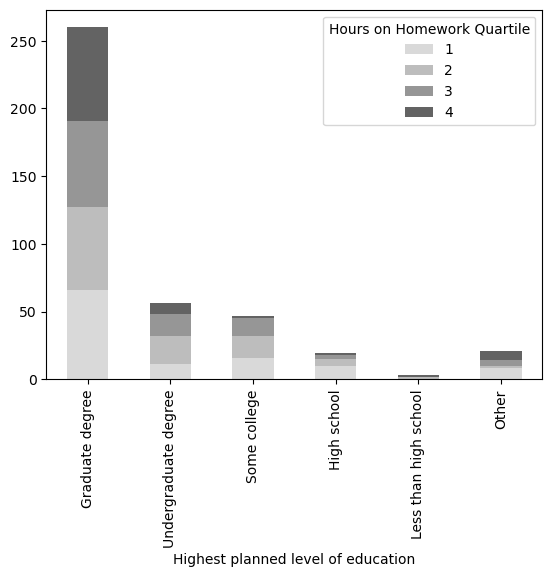

For all students:


Pressure from schoolwork,Very little,Some,A lot
Hours on Homework Quartile,,,
1,33,46,23
2,14,61,31
3,10,55,35
4,6,25,57


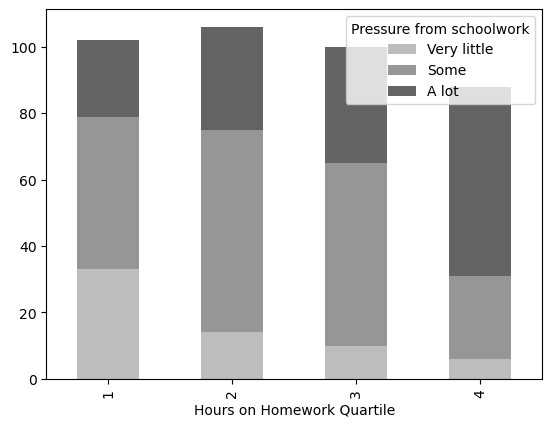

In [337]:
pressure = pd.Categorical(df_q[q_idx[34][0]], 
                          categories= ['Very little','Some','A lot'],
                          ordered=True)
order = ['Graduate degree', 'Undergraduate degree', 'Some college',
                    'High school', 'Less than high school', 'Other']
ed_level = pd.Categorical(df_q[q_idx[35][0]], categories=order, ordered=True)

ed = pd.DataFrame({'Pressure from schoolwork': pressure,
                   'Highest planned level of education': ed_level})

ct = pd.crosstab(ed['Highest planned level of education'],
                 ed['Pressure from schoolwork'])

display(ct)

ct.plot(kind='bar', stacked=True)
plt.show()

ct = pd.crosstab(ed['Highest planned level of education'],
                 ed['Pressure from schoolwork'], normalize='index')
tab20c = plt.color_sequences["tab20c"]
colors = [tab20c[i] for i in [-2, -3, -4]]
ct.plot(kind='bar', stacked=True, color=colors)
plt.show()

study_hrs = df_q['Doing_Homework_Hours'].map(to_float)
# study_hrs = study_hrs.clip(upper=study_hrs.quantile(0.95))
q = 4
study_q = pd.qcut(study_hrs, q, labels=range(1, q+1))


ct = pd.crosstab(study_q, ed['Highest planned level of education'],
                    rownames=['Hours on Homework Quartile'])
display(ct)

colors2 = [tab20c[i] for i in [-1, -2, -3, -4]]

ct.T.plot(kind='bar',
        stacked=True, color=colors2)
plt.show()


print("For all students:")
ct = pd.crosstab(study_q, ed['Pressure from schoolwork'],
                    rownames=['Hours on Homework Quartile'])
display(ct)

ct.plot(kind='bar',
        stacked=True, color=colors)
plt.show()



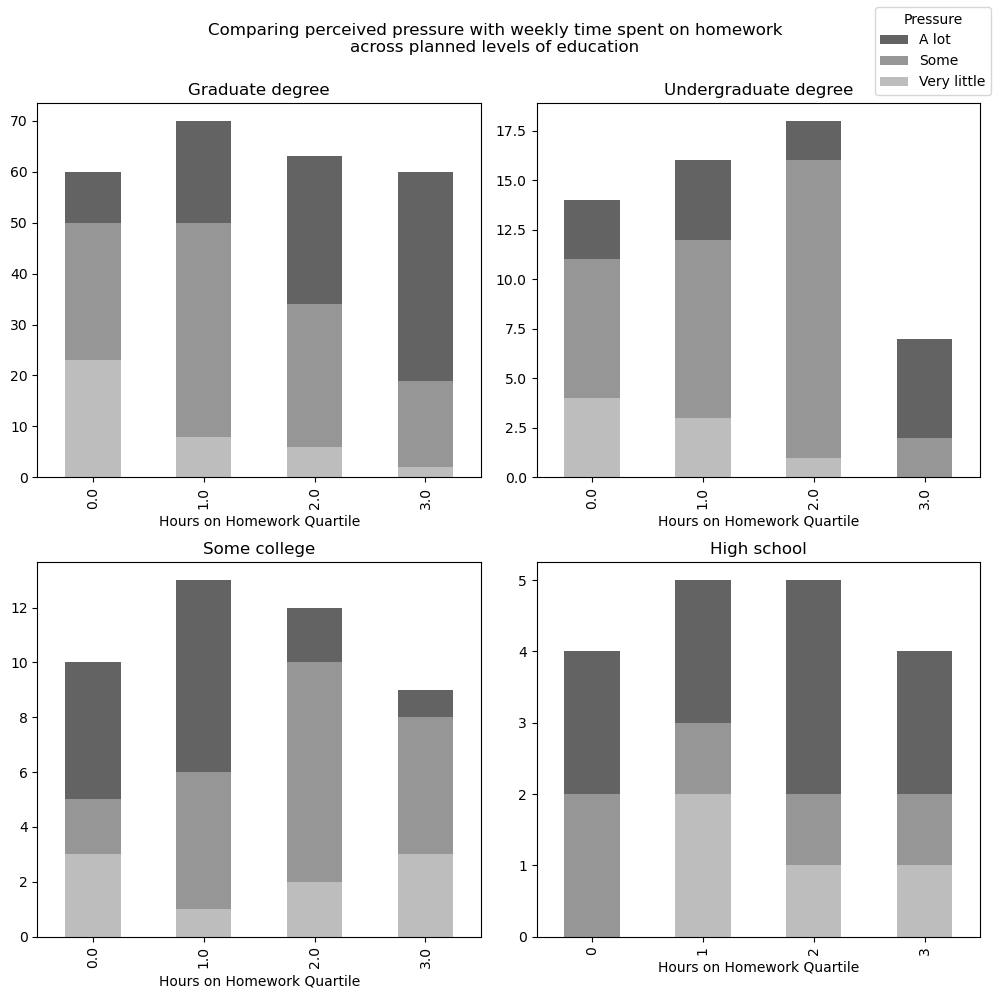

In [ ]:
# 18.03.2026

fig, axes = plt.subplots(2,2)
fig.set_size_inches(10, 10)
levels = ['Graduate degree', 'Undergraduate degree', 'Some college',
                    'High school']

for level, ax in zip(levels, axes.flatten()):

    mask = ed_level == level
    study_q = pd.qcut(study_hrs[mask], q, labels=range(1, q+1))

    ct = pd.crosstab(study_q, ed['Pressure from schoolwork'],
                    rownames=['Hours on Homework Quartile'])
    ct.plot(kind='bar', ax=ax, legend=False,
            stacked=True, color=colors)
    ax.set_title(level)

# Create shared legend.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], loc='upper right',
           title='Pressure')

fig.suptitle("Comparing perceived pressure with weekly time spent on homework\n" \
             "across planned levels of education")
fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()




